# Predicción de cancelación de clientes (churn) — Telecom

## Objetivo

El operador de telecomunicaciones quiere **anticipar qué clientes van a cancelar su contrato** para ofrecerles promociones o planes especiales antes de que se vayan.

Se construye un modelo de clasificación binaria:

- **Variable objetivo:** `churn` (1 = el cliente canceló, 0 = el cliente sigue activo).
- **Métrica principal:** **AUC-ROC**, porque mide la capacidad del modelo para ordenar a los clientes por riesgo sin depender de un umbral.
- **Métricas secundarias:** F1-score, recall y precisión sobre la clase positiva (clientes que cancelan).

## Índice

1. Configuración
2. Carga de datos
3. Limpieza y unión de tablas
4. Ingeniería de características
5. Análisis exploratorio (EDA)
6. Preparación para el modelado
7. Comparación de modelos con validación cruzada
8. Ajuste de hiperparámetros y umbral de decisión
9. Evaluación final en el conjunto de prueba
10. Conclusiones

## 1. Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 12345
TEST_SIZE = 0.2
DATA_DIR = Path("../data/raw")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Carga de datos

Los datos vienen en cuatro archivos que comparten la columna `customerID`:

| Archivo | Contenido |
|---|---|
| `contract.csv` | Fechas de inicio y fin, tipo de contrato, método de pago y cargos |
| `personal.csv` | Género, si es adulto mayor, si tiene pareja y dependientes |
| `internet.csv` | Tipo de conexión y servicios adicionales de internet |
| `phone.csv` | Si el cliente tiene varias líneas telefónicas |

In [2]:
contract = pd.read_csv(DATA_DIR / "contract.csv")
personal = pd.read_csv(DATA_DIR / "personal.csv")
internet = pd.read_csv(DATA_DIR / "internet.csv")
phone = pd.read_csv(DATA_DIR / "phone.csv")

tables = {"contract": contract, "personal": personal, "internet": internet, "phone": phone}

summary = pd.DataFrame(
    {
        "filas": {name: len(t) for name, t in tables.items()},
        "columnas": {name: t.shape[1] for name, t in tables.items()},
        "customerID_único": {name: t["customerID"].is_unique for name, t in tables.items()},
        "valores_nulos": {name: int(t.isna().sum().sum()) for name, t in tables.items()},
    }
)
summary

,filas,columnas,customerID_único,valores_nulos
contract,7043,8,True,0
personal,7043,5,True,0
internet,5517,8,True,0
phone,6361,2,True,0


In [3]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


**Observaciones:**

- Todas las tablas tienen un `customerID` único por fila y no hay valores nulos explícitos.
- `internet.csv` y `phone.csv` tienen menos filas que `contract.csv`: no todos los clientes contratan ambos servicios.
- `TotalCharges` es de tipo `object` aunque debería ser numérica; hay que revisarla.
- `EndDate` contiene `"No"` para los contratos activos y una fecha para los cancelados.

## 3. Limpieza y unión de tablas

In [5]:
df = (
    contract.merge(personal, on="customerID", how="left")
    .merge(internet, on="customerID", how="left")
    .merge(phone, on="customerID", how="left")
)

df["BeginDate"] = pd.to_datetime(df["BeginDate"])
df["EndDate"] = pd.to_datetime(df["EndDate"].replace("No", pd.NA))

# Objetivo: el cliente canceló si tiene fecha de fin
df["churn"] = df["EndDate"].notna().astype(int)

print(df.shape)
df["churn"].value_counts(normalize=True).round(3)

(7043, 21)


churn
0    0.735
1    0.265
Name: proportion, dtype: float64

### 3.1 `TotalCharges`

Buscamos los valores que no se pueden convertir a número.

In [6]:
total_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[total_numeric.isna(), ["customerID", "BeginDate", "MonthlyCharges", "TotalCharges"]]

,customerID,BeginDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,52.55,
753,3115-CZMZD,2020-02-01,20.25,
936,5709-LVOEQ,2020-02-01,80.85,
1082,4367-NUYAO,2020-02-01,25.75,
1340,1371-DWPAZ,2020-02-01,56.05,
3331,7644-OMVMY,2020-02-01,19.85,
3826,3213-VVOLG,2020-02-01,25.35,
4380,2520-SGTTA,2020-02-01,20.00,
5218,2923-ARZLG,2020-02-01,19.70,
6670,4075-WKNIU,2020-02-01,73.35,


Los 11 registros tienen `TotalCharges` vacío y **todos empezaron el 2020-02-01**, la fecha más reciente del dataset. Son clientes nuevos a los que aún no se les ha facturado, así que el valor correcto es **0** (no hace falta eliminarlos).

In [7]:
df["TotalCharges"] = total_numeric.fillna(0.0)

### 3.2 Servicios de internet y teléfono

Un valor nulo después del `merge` significa que el cliente **no contrató** ese servicio, no que el dato falte. Se rellena con `"No"` y se añaden indicadores explícitos.

In [8]:
INTERNET_ADDONS = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df["has_internet"] = df["InternetService"].notna().astype(int)
df["has_phone"] = df["MultipleLines"].notna().astype(int)

df["InternetService"] = df["InternetService"].fillna("No")
df[INTERNET_ADDONS] = df[INTERNET_ADDONS].fillna("No")
df["MultipleLines"] = df["MultipleLines"].fillna("No")

# Cada cliente debe tener al menos uno de los dos servicios
assert (df["has_internet"] + df["has_phone"] >= 1).all()
assert df.isna().drop(columns="EndDate").sum().sum() == 0

## 4. Ingeniería de características

### 4.1 Fecha de corte y antigüedad del cliente

Para calcular la antigüedad (`tenure_months`) de los clientes activos se necesita la fecha en la que se extrajeron los datos. La tomamos **de los propios datos**: es la fecha de inicio más reciente.

> ⚠️ **Corrección respecto a la versión anterior del proyecto:** antes se usaba `2021-02-01` como fecha de corte. Eso sumaba 12 meses falsos a todos los clientes activos, y ningún cliente activo podía tener menos de 12 meses. El modelo aprendía a separar las clases gracias a ese error (**fuga de datos**) y las métricas estaban infladas.

In [9]:
CUTOFF_DATE = df["BeginDate"].max()
print("Fecha de corte:", CUTOFF_DATE.date())
print("Fechas de cancelación:", sorted(df["EndDate"].dropna().dt.date.unique()))

end_or_cutoff = df["EndDate"].fillna(CUTOFF_DATE)
df["tenure_months"] = (end_or_cutoff - df["BeginDate"]).dt.days / 30.44

df.groupby("churn")["tenure_months"].describe().round(1)

Fecha de corte: 2020-02-01
Fechas de cancelación: [datetime.date(2019, 10, 1), datetime.date(2019, 11, 1), datetime.date(2019, 12, 1), datetime.date(2020, 1, 1)]


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.0,37.6,24.1,0.0,15.0,38.0,61.0,72.0
1,1869.0,18.0,19.5,1.0,2.0,10.0,29.0,72.0


### 4.2 Número de servicios adicionales

Contamos cuántos servicios extra de internet tiene contratados cada cliente.

In [10]:
df["n_addons"] = (df[INTERNET_ADDONS] == "Yes").sum(axis=1)
df["n_addons"].value_counts().sort_index()

n_addons
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

## 5. Análisis exploratorio (EDA)

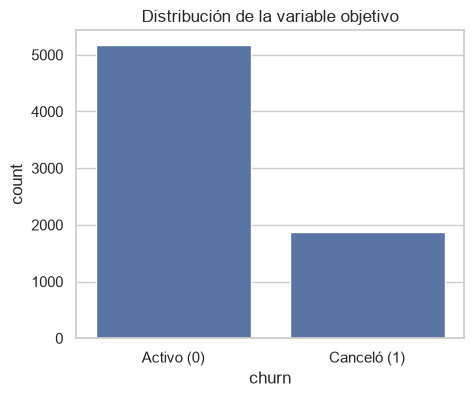

Tasa de cancelación: 26.5%


In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="churn", ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xticks([0, 1], ["Activo (0)", "Canceló (1)"])
plt.show()

print(f"Tasa de cancelación: {df['churn'].mean():.1%}")

Las clases están **desbalanceadas** (≈ 26 % de cancelaciones). Por eso no usamos la exactitud como métrica principal: un modelo que siempre predice "activo" ya tendría ≈ 74 % de exactitud.

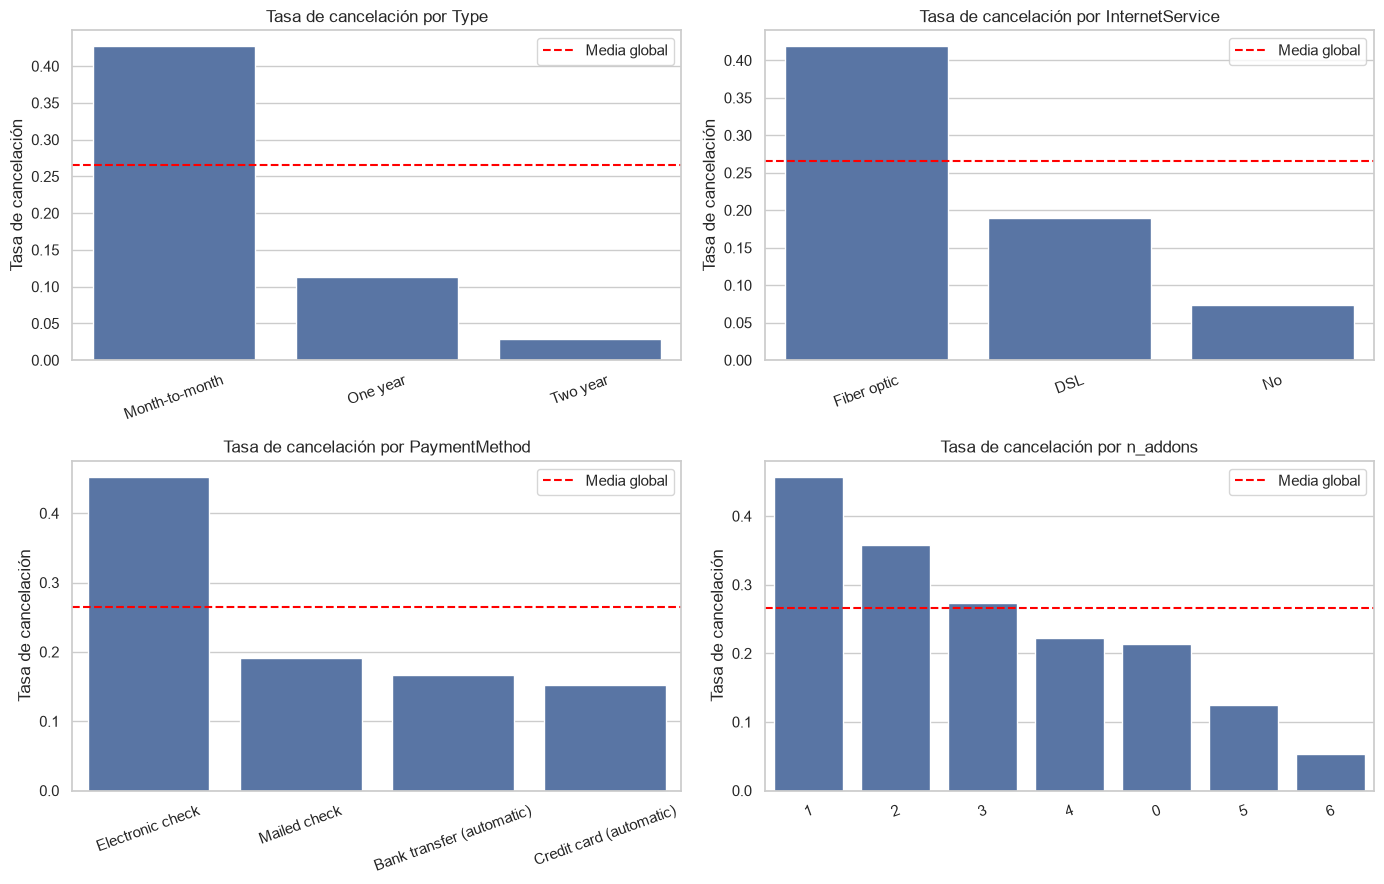

In [12]:
def plot_churn_rate(data, column, ax):
    """Grafica la tasa de cancelación por categoría de `column`."""
    rates = data.groupby(column)["churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax)
    ax.axhline(data["churn"].mean(), color="red", linestyle="--", label="Media global")
    ax.set_title(f"Tasa de cancelación por {column}")
    ax.set_xlabel("")
    ax.set_ylabel("Tasa de cancelación")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column in zip(axes.flat, ["Type", "InternetService", "PaymentMethod", "n_addons"]):
    plot_churn_rate(df, column, ax)
plt.tight_layout()
plt.show()

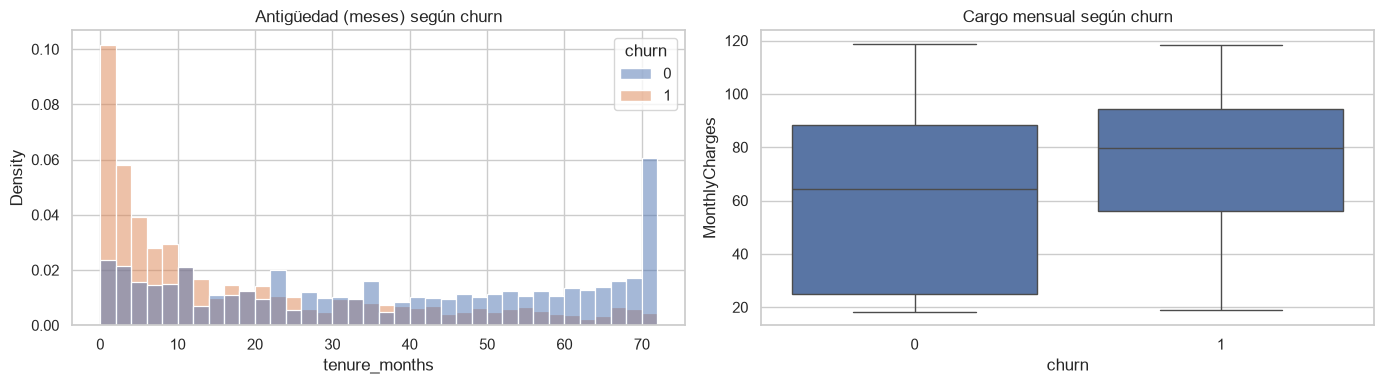

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="tenure_months", hue="churn", bins=36, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Antigüedad (meses) según churn")
sns.boxplot(data=df, x="churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Cargo mensual según churn")
plt.tight_layout()
plt.show()

**Hallazgos del EDA:**

- Los contratos **mes a mes** cancelan mucho más que los de uno o dos años.
- Los clientes con **fibra óptica** y los que pagan con **cheque electrónico** tienen una tasa de cancelación superior a la media.
- Los clientes que cancelan tienen, en general, **menos antigüedad** y **cargos mensuales más altos**.
- Tener más servicios adicionales se asocia con menos cancelaciones.

## 6. Preparación para el modelado

Todo el preprocesamiento (escalado y codificación) va dentro de un `Pipeline`. Así los transformadores **solo aprenden de los datos de entrenamiento** en cada partición, y se evita otra fuente de fuga de datos. `SMOTE` también va dentro del pipeline, de modo que solo se aplica a los pliegues de entrenamiento y nunca a los de validación.

Se descartan `customerID` (identificador) y las fechas `BeginDate`/`EndDate` (la información útil ya está en `tenure_months`; `EndDate` además revela directamente el objetivo).

In [14]:
TARGET = "churn"
NUMERIC_FEATURES = ["tenure_months", "MonthlyCharges", "TotalCharges", "n_addons"]
BINARY_FEATURES = ["SeniorCitizen", "has_internet", "has_phone"]
CATEGORICAL_FEATURES = [
    "Type",
    "PaperlessBilling",
    "PaymentMethod",
    "gender",
    "Partner",
    "Dependents",
    "InternetService",
    "MultipleLines",
    *INTERNET_ADDONS,
]
FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Entrenamiento: {X_train.shape}, prueba: {X_test.shape}")
print(f"Tasa de churn -> entrenamiento: {y_train.mean():.3f}, prueba: {y_test.mean():.3f}")

Entrenamiento: (5634, 21), prueba: (1409, 21)
Tasa de churn -> entrenamiento: 0.265, prueba: 0.265


In [15]:
preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("bin", "passthrough", BINARY_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)


def build_pipeline(model, use_smote=False):
    """Crea un pipeline de preprocesamiento + (SMOTE opcional) + modelo."""
    steps = [("prep", clone(preprocessor))]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

## 7. Comparación de modelos con validación cruzada

Se comparan cuatro modelos, con y sin SMOTE, usando **validación cruzada estratificada de 5 pliegues solo sobre el conjunto de entrenamiento**. El conjunto de prueba queda reservado para la evaluación final.

`DummyClassifier` sirve como **línea base**: cualquier modelo útil debe superarlo claramente.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["roc_auc", "f1", "recall", "precision", "accuracy"]

models = {
    "Dummy": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

cv_rows = []
for name, model in models.items():
    for use_smote in (False, True):
        scores = cross_validate(build_pipeline(model, use_smote), X_train, y_train, cv=cv, scoring=SCORING)
        row = {"modelo": name, "SMOTE": use_smote}
        row.update({metric: scores[f"test_{metric}"].mean() for metric in SCORING})
        row["roc_auc_std"] = scores["test_roc_auc"].std()
        cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
cv_results.round(3)

,modelo,SMOTE,roc_auc,f1,recall,precision,accuracy,roc_auc_std
0,XGBoost,False,0.899,0.696,0.629,0.780,0.854,0.014
1,XGBoost,True,0.892,0.686,0.646,0.732,0.843,0.014
2,LogisticRegression,False,0.847,0.601,0.548,0.665,0.807,0.014
3,LogisticRegression,True,0.846,0.632,0.795,0.525,0.754,0.013
4,RandomForest,False,0.840,0.585,0.511,0.683,0.807,0.014
5,RandomForest,True,0.834,0.603,0.589,0.619,0.794,0.014
6,Dummy,True,0.509,0.353,0.498,0.273,0.515,0.016
7,Dummy,False,0.503,0.273,0.276,0.270,0.610,0.013


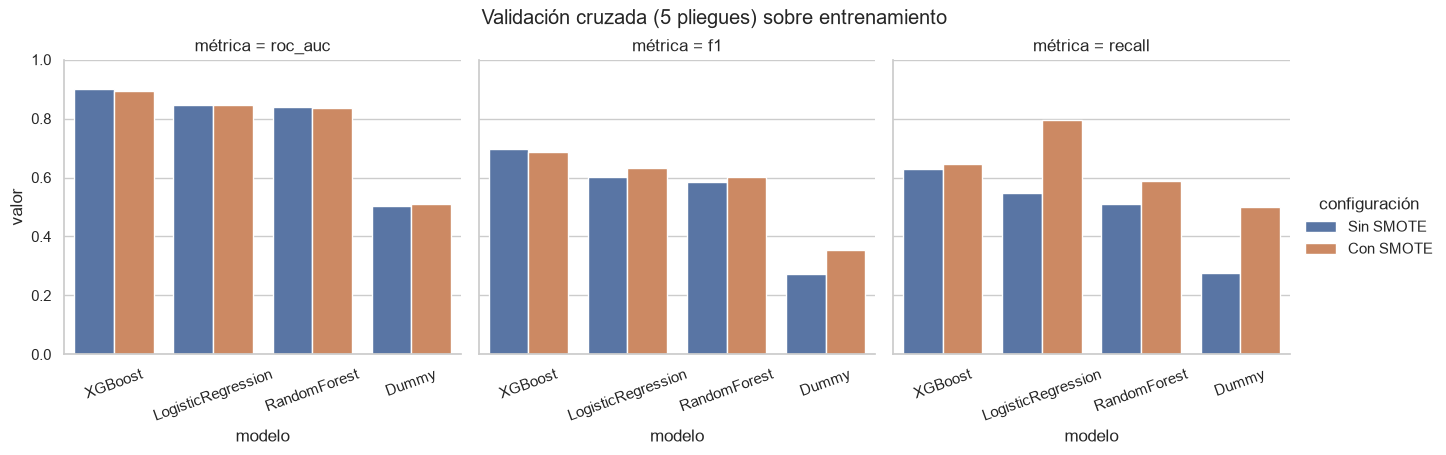

In [17]:
plot_data = cv_results.melt(
    id_vars=["modelo", "SMOTE"], value_vars=["roc_auc", "f1", "recall"], var_name="métrica", value_name="valor"
)
plot_data["configuración"] = plot_data["SMOTE"].map({False: "Sin SMOTE", True: "Con SMOTE"})

g = sns.catplot(
    data=plot_data, x="modelo", y="valor", hue="configuración", col="métrica", kind="bar", height=4, aspect=1.1
)
g.set(ylim=(0, 1))
g.set_xticklabels(rotation=20)
g.figure.suptitle("Validación cruzada (5 pliegues) sobre entrenamiento", y=1.03)
plt.show()

**Resultados de la validación cruzada:**

- Todos los modelos superan con claridad a la línea base (`Dummy`, AUC-ROC ≈ 0.5).
- **XGBoost** obtiene el mejor AUC-ROC (≈ 0.90), seguido de la regresión logística (≈ 0.85).
- **SMOTE no mejora el AUC-ROC** en ningún modelo. Lo que hace es desplazar el equilibrio entre precisión y recall (sube el recall y baja la precisión), algo que también se consigue **moviendo el umbral de decisión** sin generar datos sintéticos. Por eso continuamos sin SMOTE y ajustamos el umbral en la sección 8.2.

## 8. Ajuste de hiperparámetros y umbral de decisión

### 8.1 Búsqueda aleatoria de hiperparámetros

Se ajusta **XGBoost** (el mejor modelo en la validación cruzada) con `RandomizedSearchCV`, optimizando el AUC-ROC. No se usa SMOTE porque en la sección 7 no mejoró el AUC-ROC.

In [18]:
param_distributions = {
    "model__n_estimators": randint(100, 800),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_depth": randint(2, 8),
    "model__min_child_weight": randint(1, 10),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
}

search = RandomizedSearchCV(
    build_pipeline(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print(f"Mejor AUC-ROC en validación cruzada: {search.best_score_:.4f}")
pd.Series(search.best_params_).round(3)

Mejor AUC-ROC en validación cruzada: 0.8951


model__colsample_bytree      0.929
model__learning_rate         0.213
model__max_depth             2.000
model__min_child_weight      7.000
model__n_estimators        444.000
model__subsample             0.990
dtype: float64

Comparamos el modelo ajustado con XGBoost por defecto (sin SMOTE) de la sección 7 y nos quedamos con el que tenga **mayor AUC-ROC en validación cruzada**. Un ajuste de hiperparámetros no siempre mejora el modelo, y hay que comprobarlo en lugar de suponerlo.

In [19]:
default_row = cv_results.query("modelo == 'XGBoost' and not SMOTE").iloc[0]
print(f"XGBoost por defecto: AUC-ROC CV = {default_row['roc_auc']:.4f} ± {default_row['roc_auc_std']:.4f}")
print(f"XGBoost ajustado:    AUC-ROC CV = {search.best_score_:.4f}")

if search.best_score_ >= default_row["roc_auc"]:
    final_name = "XGBoost ajustado"
    best_model = search.best_estimator_
else:
    final_name = "XGBoost por defecto"
    best_model = build_pipeline(models["XGBoost"]).fit(X_train, y_train)

print("Modelo final:", final_name)

XGBoost por defecto: AUC-ROC CV = 0.8993 ± 0.0143
XGBoost ajustado:    AUC-ROC CV = 0.8951
Modelo final: XGBoost por defecto


### 8.2 Elección del umbral

Por defecto, un clasificador predice "cancela" si la probabilidad es ≥ 0.5. Con clases desbalanceadas ese umbral no suele ser el mejor para el F1-score.

Elegimos el umbral que **maximiza el F1** usando probabilidades *out-of-fold* del conjunto de entrenamiento, **sin mirar el conjunto de prueba**.

In [20]:
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_threshold = thresholds[np.argmax(f1_values)]

print(f"Umbral elegido: {best_threshold:.3f} (F1 out-of-fold = {f1_values.max():.4f})")

Umbral elegido: 0.401 (F1 out-of-fold = 0.7089)


## 9. Evaluación final en el conjunto de prueba

El modelo final está entrenado con todo el conjunto de entrenamiento y se evalúa **una sola vez** en el conjunto de prueba.

In [21]:
test_proba = best_model.predict_proba(X_test)[:, 1]
dummy = build_pipeline(models["Dummy"]).fit(X_train, y_train)


def evaluate(y_true, proba, threshold):
    """Calcula las métricas de clasificación para un umbral dado."""
    y_pred = (proba >= threshold).astype(int)
    return {
        "AUC-ROC": roc_auc_score(y_true, proba),
        "F1": f1_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precisión": precision_score(y_true, y_pred, zero_division=0),
        "Exactitud": accuracy_score(y_true, y_pred),
    }


test_results = pd.DataFrame(
    {
        "Dummy (línea base)": evaluate(y_test, dummy.predict_proba(X_test)[:, 1], 0.5),
        f"{final_name} (umbral 0.5)": evaluate(y_test, test_proba, 0.5),
        f"{final_name} (umbral {best_threshold:.2f})": evaluate(y_test, test_proba, best_threshold),
    }
).T
test_results.round(4)

,AUC-ROC,F1,Recall,Precisión,Exactitud
Dummy (línea base),0.4858,0.2453,0.2460,0.2447,0.5983
XGBoost por defecto (umbral 0.5),0.9024,0.7270,0.6658,0.8006,0.8673
XGBoost por defecto (umbral 0.40),0.9024,0.7290,0.7299,0.7280,0.8559


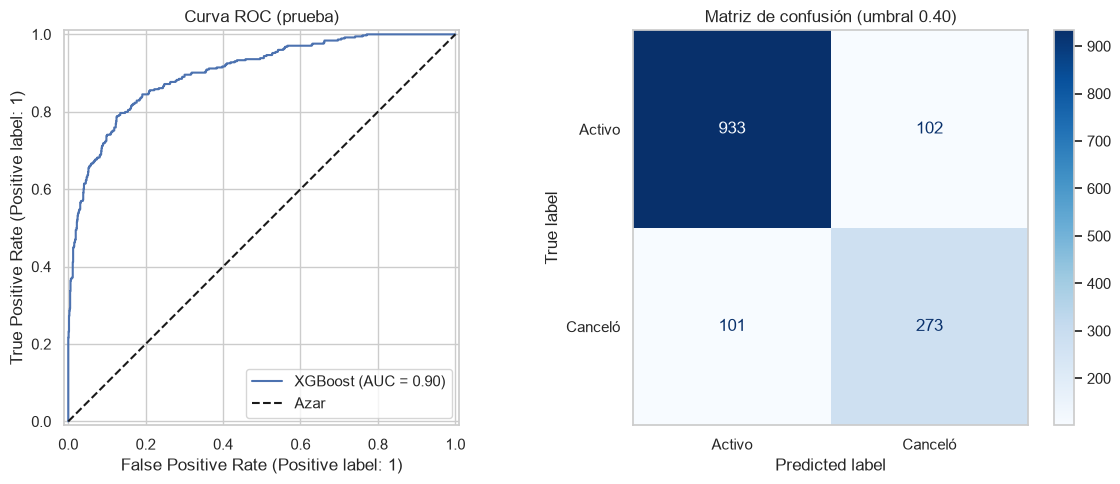

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, name="XGBoost", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Azar")
axes[0].set_title("Curva ROC (prueba)")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (test_proba >= best_threshold).astype(int),
    display_labels=["Activo", "Canceló"],
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title(f"Matriz de confusión (umbral {best_threshold:.2f})")
axes[1].grid(False)
plt.tight_layout()
plt.show()

### 9.1 Variables más importantes

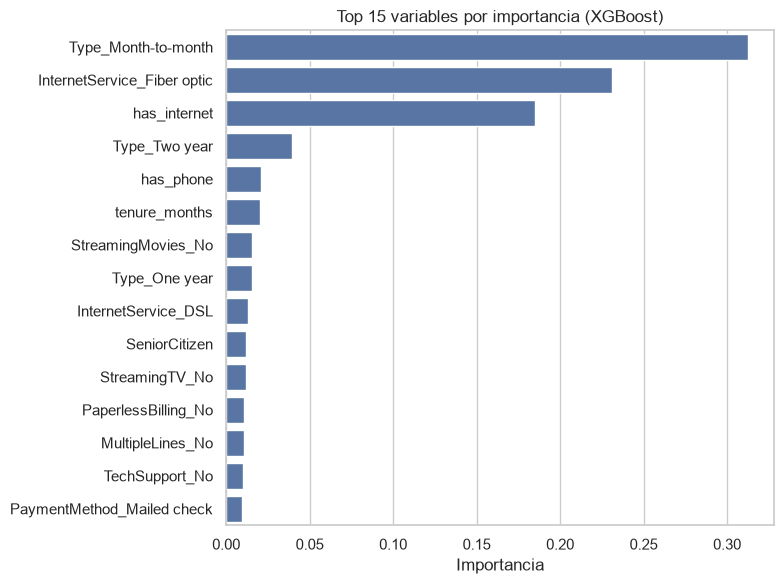

In [23]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importances = pd.Series(best_model.named_steps["model"].feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index.str.replace(r"^\w+__", "", regex=True), ax=ax)
ax.set_title("Top 15 variables por importancia (XGBoost)")
ax.set_xlabel("Importancia")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 10. Conclusiones

### Resultados

| Modelo (conjunto de prueba) | AUC-ROC | F1 | Recall | Precisión | Exactitud |
|---|---|---|---|---|---|
| Dummy (línea base) | 0.49 | 0.25 | 0.25 | 0.24 | 0.60 |
| **XGBoost, umbral 0.40** | **0.90** | **0.73** | **0.73** | **0.73** | **0.86** |

- El modelo final es **XGBoost con los hiperparámetros por defecto** y un **umbral de decisión de 0.40**, elegido en validación cruzada para maximizar el F1.
- En el conjunto de prueba alcanza un **AUC-ROC de 0.90** (≈ 0.90 también en validación cruzada, así que no hay señales de sobreajuste) y detecta **3 de cada 4 clientes que cancelan** con una precisión del 73 %.

### Aprendizajes técnicos

1. **Fuga de datos por la fecha de corte.** La versión anterior usaba `2021-02-01` en lugar de `2020-02-01`, lo que inflaba artificialmente las métricas (F1 0.87 frente a 0.73 real). Conviene sacar este tipo de fechas **de los propios datos** y desconfiar de resultados demasiado buenos.
2. **El preprocesamiento va dentro de un `Pipeline`**, para que escaladores y codificadores no vean los datos de validación ni de prueba.
3. **El AUC-ROC se calcula con probabilidades**, no con predicciones ya convertidas a 0/1.
4. **SMOTE no mejoró el AUC-ROC**; ajustar el umbral de decisión consigue el mismo efecto sobre el recall de forma más simple.
5. **El ajuste de hiperparámetros no siempre mejora el modelo**: la búsqueda aleatoria no superó a los valores por defecto, y lo comprobamos antes de elegir.

### Recomendaciones para el negocio

- Los principales factores de riesgo son el **contrato mes a mes**, la **fibra óptica** y la **poca antigüedad** del cliente.
- Acciones sugeridas: ofrecer **descuentos por pasar a contratos de 1 o 2 años**, revisar la **relación calidad/precio de la fibra óptica** y reforzar la **atención durante los primeros meses** del cliente.
- El umbral se puede ajustar según el coste de las campañas: un umbral más bajo detecta más cancelaciones a cambio de contactar a más clientes que no se iban a ir.

### Limitaciones y próximos pasos

- Todas las cancelaciones ocurren entre **octubre de 2019 y enero de 2020**. El modelo debería validarse con datos de periodos posteriores antes de usarlo en producción.
- Probar la calibración de probabilidades y modelos como LightGBM o CatBoost.
- Estimar el impacto económico de las campañas de retención para elegir el umbral según el beneficio esperado.